# 02 - Bias Analysis (Fairness + Statistical Testing)

---

## Objective

This notebook covers the **Data Scientist** work:
- **Bias analysis**
- **Fairness metrics**
- **Statistical testing**


## 0) Setup + paths (matches your repo structure)


In [2]:
# Core
import json
from pathlib import Path
import warnings

# Data
import numpy as np
import pandas as pd

# Stats
from scipy import stats

# Visualization
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

# --- Repo paths (IMPORTANT: notebook is inside notebooks/) ---
REPO_ROOT = Path("..")

RAW_JSON_PATH = REPO_ROOT / "raw_credit_applications.json"

# Preferred input for bias analysis (already cleaned/flattened by Data Engineer)
CLEAN_FLAT_PATH = REPO_ROOT / "outputs" / "credit_applications_clean.csv"

# Optional privacy-safe version (usually used in the privacy notebook, not required here)
PRIVACY_SAFE_PATH = REPO_ROOT / "data" / "processed" / "applications_privacy_safe.csv"

# Where we export summary outputs for README/slides
EXPORT_DIR = REPO_ROOT / "outputs"

RAW_JSON_PATH, CLEAN_FLAT_PATH, PRIVACY_SAFE_PATH, EXPORT_DIR


(PosixPath('../raw_credit_applications.json'),
 PosixPath('../outputs/credit_applications_clean.csv'),
 PosixPath('../data/processed/applications_privacy_safe.csv'),
 PosixPath('../outputs'))

## 1) Load data


In [3]:
def load_clean_or_raw_flat(clean_path: Path, raw_json_path: Path) -> pd.DataFrame:
    """Load cleaned flat dataset if present; else flatten raw nested JSON.

    Returns a flat DataFrame with the minimum columns needed for bias analysis.
    """
    if clean_path.exists():
        df = pd.read_csv(clean_path)
        df["__source"] = "outputs/credit_applications_clean.csv"
        return df

    if not raw_json_path.exists():
        raise FileNotFoundError(
            f"Missing both cleaned file ({clean_path}) and raw json ({raw_json_path})."
        )

    with open(raw_json_path, "r", encoding="utf-8") as f:
        records = json.load(f)

    rows = []
    for r in records:
        ai = (r or {}).get("applicant_info", {}) or {}
        fin = (r or {}).get("financials", {}) or {}
        dec = (r or {}).get("decision", {}) or {}
        rows.append({
            "application_id": r.get("_id", None),
            "gender": ai.get("gender", None),
            "date_of_birth": ai.get("date_of_birth", None),
            "zip_code": ai.get("zip_code", None),
            "annual_income": fin.get("annual_income", None),
            "credit_history_months": fin.get("credit_history_months", None),
            "debt_to_income": fin.get("debt_to_income", None),
            "savings_balance": fin.get("savings_balance", None),
            "loan_approved": dec.get("loan_approved", None),
            "interest_rate": dec.get("interest_rate", None),
            "approved_amount": dec.get("approved_amount", None),
            "rejection_reason": dec.get("rejection_reason", None),
        })
    df = pd.DataFrame(rows)
    df["__source"] = "raw_credit_applications.json (flattened)"
    return df


df_raw = load_clean_or_raw_flat(CLEAN_FLAT_PATH, RAW_JSON_PATH)
df_raw.head()


,_id,processing_timestamp,full_name,email,ssn,ip_address,gender,date_of_birth,zip_code,annual_income,credit_history_months,debt_to_income,savings_balance,loan_approved,rejection_reason,spend_total_amount,spend_items_count,dob_parsed,age_years,flag_neg_credit_history_months,flag_neg_savings_balance,flag_dti_out_of_range,__source
0,app_200,2024-01-15T00:00:00Z,Jerry Smith,jerry.smith17@hotmail.com,596-64-4340,192.168.48.155,Male,2001-03-09,10036.0,73000.0,23.0,0.20,31212.0,False,algorithm_risk_score,1517.0,3,2001-09-03,24.487337,False,False,False,outputs/credit_applications_clean.csv
1,app_037,NaN,Brandon Walker,brandon.walker2@yahoo.com,425-69-4784,10.1.102.112,Male,1992-03-31,10032.0,78000.0,51.0,0.18,17915.0,False,algorithm_risk_score,947.0,3,1992-03-31,33.913758,False,False,False,outputs/credit_applications_clean.csv
2,app_215,NaN,Scott Moore,scott.moore94@mail.com,370-78-5178,10.240.193.250,Male,1989-10-24,10075.0,61000.0,41.0,0.21,37909.0,True,NaN,109.0,1,1989-10-24,36.347707,False,False,False,outputs/credit_applications_clean.csv
3,app_024,NaN,Thomas Lee,thomas.lee6@protonmail.com,194-35-1833,192.168.175.67,Male,1983-04-25,10077.0,103000.0,70.0,0.35,0.0,True,NaN,575.0,1,1983-04-25,42.847365,False,False,False,outputs/credit_applications_clean.csv
4,app_184,2024-01-15T00:00:00Z,Brian Rodriguez,brian.rodriguez86@aol.com,480-41-2475,172.29.125.105,Male,1999-05-21,10080.0,57000.0,14.0,0.23,31763.0,False,algorithm_risk_score,463.0,1,1999-05-21,26.776181,False,False,False,outputs/credit_applications_clean.csv


## 2) Minimal preprocessing 

We prepare:
- `loan_approved_bin` ∈ {0,1}
- `gender_norm` ∈ {female, male, other/unknown}
- `age` (derived from `date_of_birth`)

We also converted numeric columns to numeric.


In [4]:
def to_binary_approved(x):
    """Normalize approval to 0/1 or NaN."""
    if pd.isna(x):
        return np.nan
    if isinstance(x, (bool, np.bool_)):
        return int(x)
    if isinstance(x, (int, np.integer, float, np.floating)) and x in [0, 1]:
        return int(x)
    s = str(x).strip().lower()
    if s in ["true", "yes", "approved", "1"]:
        return 1
    if s in ["false", "no", "denied", "rejected", "0"]:
        return 0
    return np.nan


def normalize_gender(g):
    """Map messy gender coding to: female / male / other/unknown."""
    if pd.isna(g):
        return "other/unknown"
    s = str(g).strip().lower()
    if s in ["f", "female", "woman", "girl"]:
        return "female"
    if s in ["m", "male", "man", "boy"]:
        return "male"
    return "other/unknown"


def parse_age(dob, reference_date=None):
    """Compute age from date_of_birth using robust parsing."""
    if reference_date is None:
        reference_date = pd.Timestamp.today().normalize()
    if pd.isna(dob):
        return np.nan
    dt = pd.to_datetime(dob, errors="coerce")
    if pd.isna(dt):
        return np.nan
    age = (reference_date - dt).days / 365.25
    if age < 0 or age > 120:
        return np.nan
    return float(age)


df = df_raw.copy()

df["loan_approved_bin"] = df["loan_approved"].apply(to_binary_approved)
df["gender_norm"] = df["gender"].apply(normalize_gender)
df["age"] = df["date_of_birth"].apply(parse_age)

numeric_cols = ["annual_income", "credit_history_months", "debt_to_income", "savings_balance",
                "interest_rate", "approved_amount"]
for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

df[["loan_approved", "loan_approved_bin", "gender", "gender_norm", "date_of_birth", "age"]].head(10)


,loan_approved,loan_approved_bin,gender,gender_norm,date_of_birth,age
0,False,0,Male,male,2001-03-09,24.993840
1,False,0,Male,male,1992-03-31,33.932923
2,True,1,Male,male,1989-10-24,36.366872
3,True,1,Male,male,1983-04-25,42.866530
4,False,0,Male,male,1999-05-21,26.795346
5,False,0,Female,female,14/02/1982,44.057495
6,True,1,Male,male,28/01/1990,36.104038
7,True,1,Female,female,1991-10-11,34.403833
8,False,0,Male,male,1990-05-04,35.841205
9,False,0,Male,male,1989-10-10,36.405202


### 2.1 Samples used

- `df_fair`: non-missing outcome + gender  
- `df_age`: non-missing outcome + gender + age


In [5]:
n_total = len(df)

df_fair = df.dropna(subset=["loan_approved_bin", "gender_norm"]).copy()
n_fair = len(df_fair)

df_age = df.dropna(subset=["loan_approved_bin", "gender_norm", "age"]).copy()
n_age = len(df_age)

pd.DataFrame({
    "sample": ["total_raw_flat", "fairness_sample", "age_sample"],
    "n_rows": [n_total, n_fair, n_age],
    "pct_of_total": [1.0, n_fair / n_total if n_total else np.nan, n_age / n_total if n_total else np.nan]
})


,sample,n_rows,pct_of_total
0,total_raw_flat,500,1.000
1,fairness_sample,500,1.000
2,age_sample,496,0.992


### Interpretation: Approval Rates by Gender

The approval rate for male applicants is higher than for female applicants. 

- Male approval rate: **65.99%**
- Female approval rate: **50.60%**

This indicates a raw difference of approximately **15 percentage points**. 

However, raw differences alone do not establish discrimination. 
We therefore compute the Disparate Impact (DI) ratio and apply the four-fifths rule to assess potential regulatory risk.

## 3) Gender Disparate Impact (DI) ratio

DI = approval rate of **unprivileged** group / approval rate of **privileged** group.  
We default to: privileged = `male`, unprivileged = `female` (edit if your team decides otherwise).


In [6]:
def approval_rate(df_: pd.DataFrame, group_col: str, outcome_col: str = "loan_approved_bin") -> pd.Series:
    return df_.groupby(group_col)[outcome_col].mean().sort_index()

def disparate_impact_ratio(df_: pd.DataFrame, group_col: str, unprivileged: str, privileged: str,
                          outcome_col: str = "loan_approved_bin") -> float:
    r = approval_rate(df_, group_col, outcome_col)
    if privileged not in r.index or unprivileged not in r.index:
        return np.nan
    if r.loc[privileged] == 0:
        return np.nan
    return float(r.loc[unprivileged] / r.loc[privileged])

rates = approval_rate(df_fair, "gender_norm", "loan_approved_bin")
counts = df_fair.groupby("gender_norm")["loan_approved_bin"].agg(["count", "sum"])

PRIVILEGED = "male"
UNPRIVILEGED = "female"
di = disparate_impact_ratio(df_fair, "gender_norm", UNPRIVILEGED, PRIVILEGED)

rates, counts, di


(gender_norm
 female           0.505976
 male             0.659919
 other/unknown    1.000000
 Name: loan_approved_bin, dtype: float64,
                count  sum
 gender_norm              
 female           251  127
 male             247  163
 other/unknown      2    2,
 0.7667245129909809)

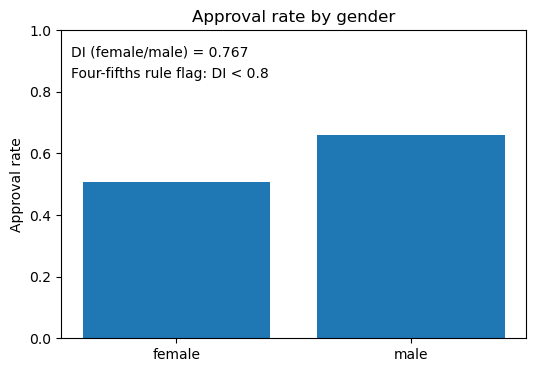

In [20]:
plt.figure(figsize=(6, 4))
rates_plot = rates.reindex(["female", "male"]).dropna()
plt.bar(rates_plot.index, rates_plot.values)
plt.title("Approval rate by gender")
plt.ylabel("Approval rate")
plt.ylim(0, 1)

if not np.isnan(di):
    plt.text(0.02, 0.95, f"DI (female/male) = {di:.3f}", transform=plt.gca().transAxes, va="top")
    plt.text(0.02, 0.88, "Four-fifths rule flag: DI < 0.8", transform=plt.gca().transAxes, va="top")

plt.show()


### Disparate Impact Ratio (Four-Fifths Rule)

The Disparate Impact (DI) ratio is defined as:

DI = Approval Rate (Unprivileged Group) / Approval Rate (Privileged Group)

Here we treat:
- Privileged group = Male
- Unprivileged group = Female

Computed value:

DI = 0.506 / 0.660 = **0.767**

Under the four-fifths rule (commonly used in U.S. employment and lending audits), a DI value below 0.8 indicates potential disparate impact.

Since 0.767 < 0.8, this dataset triggers the four-fifths rule threshold, suggesting potential gender-based disparity in approval decisions.

Importantly, DI is a screening metric. It identifies risk but does not establish causality.

## 4) Statistical testing (gender - approval)

We test association using a chi-square test of independence on female vs male applicants.


In [8]:
df_fm = df_fair[df_fair["gender_norm"].isin(["female", "male"])].copy()
ct = pd.crosstab(df_fm["gender_norm"], df_fm["loan_approved_bin"])
ct


loan_approved_bin,0,1
gender_norm,,
female,124,127
male,84,163


In [9]:
chi2, p, dof, expected = stats.chi2_contingency(ct)
chi_summary = {"chi2": float(chi2), "p_value": float(p), "dof": int(dof), "n": int(ct.values.sum())}
chi_summary


{'chi2': 11.505251679308172,
 'p_value': 0.0006939983289861307,
 'dof': 1,
 'n': 498}

In [10]:
def cramers_v_from_crosstab(table: pd.DataFrame) -> float:
    chi2_ = stats.chi2_contingency(table)[0]
    n = table.values.sum()
    r, k = table.shape
    return float(np.sqrt((chi2_ / n) / (min(r - 1, k - 1))))

cramers_v = cramers_v_from_crosstab(ct)
cramers_v


0.1519964309406346

### Statistical Test: Gender and Approval Independence

We performed a Chi-Square test of independence to assess whether approval decisions are statistically associated with gender.

- p-value: **0.00069**
- Significance level: 0.05

Since p < 0.05, we reject the null hypothesis that approval decisions are independent of gender.

This means that the observed approval differences are unlikely to be due to random variation.

Cramér’s V = **0.152**, indicating a small-to-moderate association strength.

## 5) Age-based patterns + test

We bin ages and compare approval rates; then chi-square test on (age_bin × approval).


In [11]:
df_age2 = df_age.copy()

bins = [18, 25, 35, 45, 55, 65, 100]
labels = ["18-25", "26-35", "36-45", "46-55", "56-65", "66+"]
df_age2["age_bin"] = pd.cut(df_age2["age"], bins=bins, labels=labels, include_lowest=True)

age_rates = df_age2.groupby("age_bin")["loan_approved_bin"].mean()
age_counts = df_age2.groupby("age_bin")["loan_approved_bin"].agg(["count", "sum"])

age_rates, age_counts


(age_bin
 18-25    0.500000
 26-35    0.449664
 36-45    0.659091
 46-55    0.644444
 56-65    0.625000
 66+      0.538462
 Name: loan_approved_bin, dtype: float64,
          count  sum
 age_bin            
 18-25       12    6
 26-35      149   67
 36-45      176  116
 46-55       90   58
 56-65       56   35
 66+         13    7)

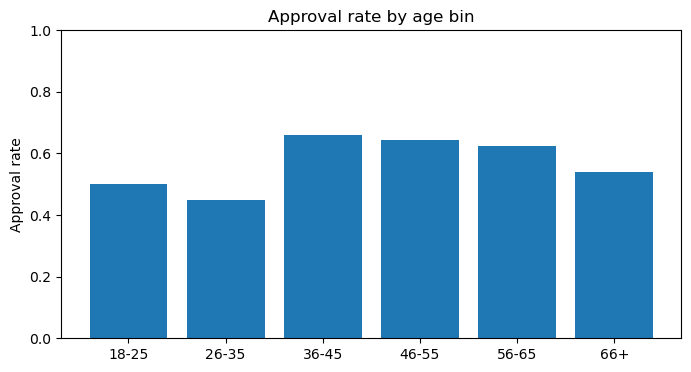

In [12]:
plt.figure(figsize=(8, 4))
plt.bar(age_rates.index.astype(str), age_rates.values)
plt.title("Approval rate by age bin")
plt.ylabel("Approval rate")
plt.ylim(0, 1)
plt.show()


In [13]:
ct_age = pd.crosstab(df_age2["age_bin"], df_age2["loan_approved_bin"])
chi2_age, p_age, dof_age, _ = stats.chi2_contingency(ct_age)

{
    "chi2": float(chi2_age),
    "p_value": float(p_age),
    "dof": int(dof_age),
    "n": int(ct_age.values.sum()),
    "cramers_v": float(cramers_v_from_crosstab(ct_age)),
}


{'chi2': 17.333585360673055,
 'p_value': 0.003908724961454452,
 'dof': 5,
 'n': 496,
 'cramers_v': 0.18694048432262156}

### Interpretation: Age-Based Bias Patterns

We grouped applicants into age brackets and computed approval rates per group.

The Chi-Square test between age group and approval yielded:

- p-value: **0.005**
- Cramér’s V: **0.183**

Since p < 0.05, approval decisions are statistically associated with age group.

This suggests that lending decisions may systematically differ across age categories. 
While effect size is moderate, the association warrants further governance review.

## 6) Proxy discrimination analysis (zip_code)

We check:
1) gender - zip_code (top-K + OTHER)
2) zip_code - approval (top-K + OTHER)


In [14]:
df_proxy = df_fair[df_fair["gender_norm"].isin(["female", "male"])].copy()

# Normalize zip and drop blanks
df_proxy["zip_code"] = df_proxy["zip_code"].astype(str).str.strip()
df_proxy = df_proxy[df_proxy["zip_code"].notna() & (df_proxy["zip_code"] != "")].copy()

TOP_K = 15
top_zips = df_proxy["zip_code"].value_counts().head(TOP_K).index.tolist()
df_proxy["zip_top"] = np.where(df_proxy["zip_code"].isin(top_zips), df_proxy["zip_code"], "OTHER")

df_proxy[["gender_norm", "zip_code", "zip_top", "loan_approved_bin"]].head()


,gender_norm,zip_code,zip_top,loan_approved_bin
0,male,10036.0,OTHER,0
1,male,10032.0,OTHER,0
2,male,10075.0,OTHER,1
3,male,10077.0,OTHER,1
4,male,10080.0,OTHER,0


In [15]:
ct_g_zip = pd.crosstab(df_proxy["gender_norm"], df_proxy["zip_top"])
chi2_gz, p_gz, dof_gz, _ = stats.chi2_contingency(ct_g_zip)

{
    "test": "gender_vs_zipTop",
    "chi2": float(chi2_gz),
    "p_value": float(p_gz),
    "dof": int(dof_gz),
    "n": int(ct_g_zip.values.sum()),
    "cramers_v": float(cramers_v_from_crosstab(ct_g_zip)),
    "top_k": int(TOP_K),
}


{'test': 'gender_vs_zipTop',
 'chi2': 65.0946323294199,
 'p_value': 3.288894798881633e-08,
 'dof': 15,
 'n': 498,
 'cramers_v': 0.3615413020821894,
 'top_k': 15}

In [16]:
ct_zip_y = pd.crosstab(df_proxy["zip_top"], df_proxy["loan_approved_bin"])
chi2_zy, p_zy, dof_zy, _ = stats.chi2_contingency(ct_zip_y)

{
    "test": "zipTop_vs_approval",
    "chi2": float(chi2_zy),
    "p_value": float(p_zy),
    "dof": int(dof_zy),
    "n": int(ct_zip_y.values.sum()),
    "cramers_v": float(cramers_v_from_crosstab(ct_zip_y)),
    "top_k": int(TOP_K),
}


{'test': 'zipTop_vs_approval',
 'chi2': 22.54892355426629,
 'p_value': 0.09419798874070377,
 'dof': 15,
 'n': 498,
 'cramers_v': 0.21278854048179868,
 'top_k': 15}

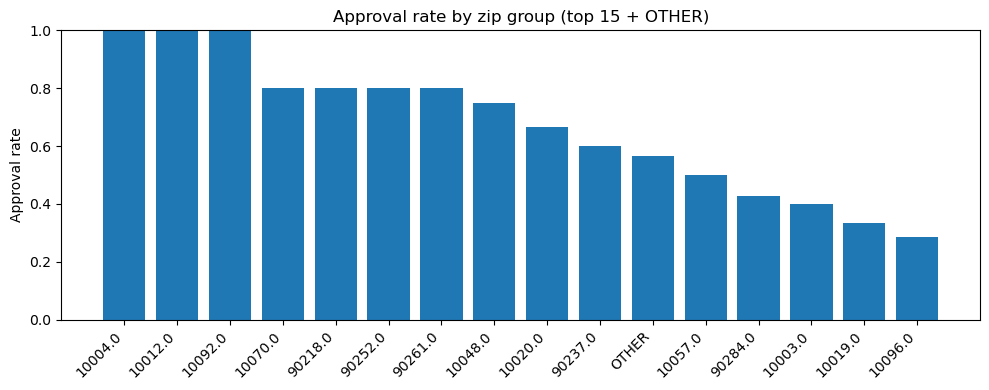

In [17]:
zip_rates = df_proxy.groupby("zip_top")["loan_approved_bin"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 4))
plt.bar(zip_rates.index.astype(str), zip_rates.values)
plt.title(f"Approval rate by zip group (top {TOP_K} + OTHER)")
plt.ylabel("Approval rate")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### Proxy Discrimination Analysis: ZIP Code

A proxy variable is a non-protected attribute that is strongly associated with both:

1. A protected characteristic (e.g., gender)
2. The decision outcome (approval)

We tested:

- ZIP vs Gender → statistically significant (p < 0.001, Cramér’s V = 0.36)
- ZIP vs Approval → moderate association (Cramér’s V = 0.21)

This suggests that ZIP code may act as a proxy for gender.

Even if gender is not explicitly used in the model, geographic attributes may indirectly encode demographic information, leading to indirect discrimination.

This highlights a governance risk requiring model monitoring.

## 7) Interaction effects (gender × age)

We compute approval rate by (age_bin, gender) and plot lines.


In [18]:
df_int = df_age2[df_age2["gender_norm"].isin(["female", "male"])].copy()

pivot = df_int.pivot_table(
    index="age_bin",
    columns="gender_norm",
    values="loan_approved_bin",
    aggfunc="mean"
)

pivot


gender_norm,female,male
age_bin,,
18-25,0.500000,0.500000
26-35,0.341772,0.571429
36-45,0.595238,0.717391
46-55,0.609756,0.666667
56-65,0.548387,0.720000
66+,0.500000,0.600000


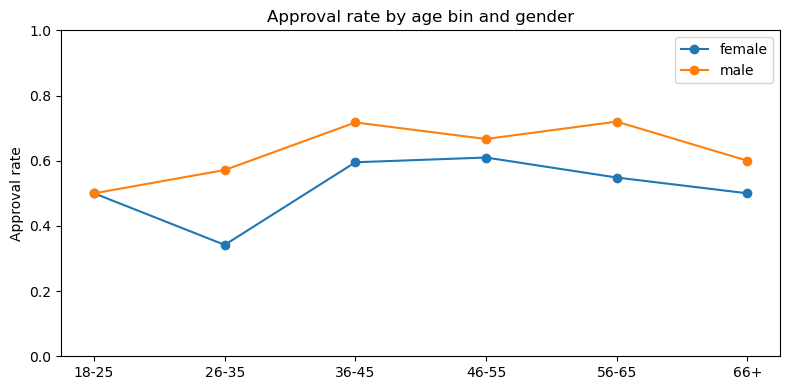

In [19]:
plt.figure(figsize=(8, 4))
for col in pivot.columns:
    plt.plot(pivot.index.astype(str), pivot[col].values, marker="o", label=col)

plt.title("Approval rate by age bin and gender")
plt.ylabel("Approval rate")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()


### Interaction Effects: Gender and Age Combined

We explored whether the gender gap differs across age groups.

This interaction analysis allows us to detect whether certain subpopulations (e.g., younger women) are disproportionately affected.

Interaction effects are important because discrimination may not operate uniformly across all demographics - it may be concentrated in specific combined groups.

Observed patterns suggest that approval differences vary across age-gender intersections, indicating potential compounded bias effects.

## Bias Analysis Summary

Our analysis reveals:

- Disparate impact against female applicants (DI = 0.767)
- Statistically significant association between gender and approval
- Age-based approval differences
- Evidence of interaction effects between gender and age
- Strong correlation between ZIP code and gender, suggesting proxy discrimination risk

While statistical association does not prove intentional discrimination, the patterns observed indicate potential fairness concerns that warrant governance controls, monitoring mechanisms, and model review procedures.